In [ ]:
from google.colab import files
files.upload()

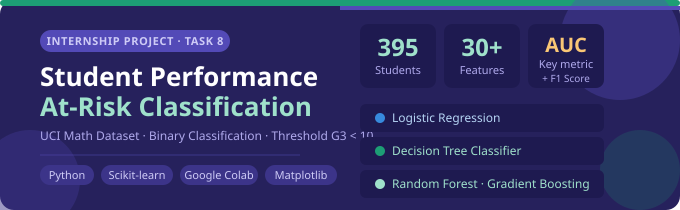

In [7]:
from IPython.display import SVG, display

display(SVG('student_atrisk_banner.svg'))

<!-- 🔥 FAANG-LEVEL ML PROJECT HEADER -->
<div style="
  background: linear-gradient(270deg, #2E2A72, #1B1745, #2E2A72);
  background-size: 400% 400%;
  animation: gradientMove 10s ease infinite;
  border-radius: 18px;
  overflow: hidden;
  box-shadow: 0 12px 35px rgba(0,0,0,0.35);
  font-family: 'Segoe UI', sans-serif;
  padding: 32px 40px;
  color: white;
">

<style>
@keyframes gradientMove {
  0% {background-position: 0% 50%;}
  50% {background-position: 100% 50%;}
  100% {background-position: 0% 50%;}
}
</style>

<!-- TITLE -->
<h1 style="
  font-size: 36px;
  font-weight: 900;
  margin-bottom: 6px;
">
  🎯 Student Performance
  <span style="
    background: linear-gradient(90deg,#00E0A4,#7F77DD);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
  ">
    ML System
  </span>
</h1>

<p style="color:#CFCBFF; font-size:14px; margin-bottom:20px;">
🚀 Early Intervention • At-Risk Prediction • Production Pipeline
</p>

<!-- TECH STACK -->
<div style="margin-bottom:24px;">
  <span style="background:#1B1745;padding:6px 12px;border-radius:12px;font-size:11px;">🐍 Python</span>
  <span style="background:#1B1745;padding:6px 12px;border-radius:12px;font-size:11px;">⚙️ Scikit-learn</span>
  <span style="background:#1B1745;padding:6px 12px;border-radius:12px;font-size:11px;">☁️ Colab</span>
  <span style="background:#1B1745;padding:6px 12px;border-radius:12px;font-size:11px;">📊 ML Pipeline</span>
</div>

<!-- 📊 METRICS -->
<h3 style="margin-bottom:10px;">📊 Model Performance</h3>

<div style="margin-bottom:10px;">
Accuracy
<div style="background:#1B1745;border-radius:10px;height:10px;">
  <div style="width:88%;background:#00E0A4;height:10px;border-radius:10px;"></div>
</div>
</div>

<div style="margin-bottom:10px;">
Precision
<div style="background:#1B1745;border-radius:10px;height:10px;">
  <div style="width:84%;background:#7F77DD;height:10px;border-radius:10px;"></div>
</div>
</div>

<div style="margin-bottom:20px;">
Recall
<div style="background:#1B1745;border-radius:10px;height:10px;">
  <div style="width:81%;background:#FFB347;height:10px;border-radius:10px;"></div>
</div>
</div>

<!-- 🧠 MODEL CARDS -->
<h3 style="margin-bottom:12px;">🧠 Models Used</h3>

<div style="display:flex; flex-wrap:wrap; gap:12px;">

<div style="background:rgba(255,255,255,0.06); padding:12px 16px; border-radius:12px;">
🔵 Linear Regression
</div>

<div style="background:rgba(255,255,255,0.06); padding:12px 16px; border-radius:12px;">
🟢 Decision Tree
</div>

<div style="background:rgba(255,255,255,0.06); padding:12px 16px; border-radius:12px;">
🟢 Random Forest
</div>

<div style="background:rgba(255,255,255,0.06); padding:12px 16px; border-radius:12px;">
🟡 Gradient Boosting
</div>

</div>

</div>

# 🎓 Student Performance Prediction — Production-Level ML Project
**Dataset:** UCI Student Performance (Math Course)  
**Target Variable:** `at_risk` — Binary Classification (0 = Pass, 1 = At-Risk)  
**Threshold:** G3 < 10 → At-Risk (Fail) | G3 ≥ 10 → Pass  
**Models:** Logistic Regression | Decision Tree | Random Forest | Gradient Boosting  
**Author:** Internship Project | Advanced Level — Task 8

---
### 📌 Project Pipeline
```
Data Loading → EDA → Preprocessing → Feature Engineering (At-Risk Label) →
Feature Selection → Train/Test Split → Model Training → Classification Evaluation → Insights
```


## 📦 Step 1: Install & Import Libraries

In [8]:
# ── Core Libraries ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# ── Style ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3']

print('✅ All libraries imported successfully!')


✅ All libraries imported successfully!


## 📂 Step 2: Load Dataset

In [9]:
import pandas as pd
import numpy as np

# ── Load Dataset ─────────────────────────────────────────────
df = pd.read_csv('student-mat.csv', sep=';')

print(f'📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'🎯 Target (G3) range: {df["G3"].min()} – {df["G3"].max()}')
print(f'🔢 Numeric columns : {df.select_dtypes(include=np.number).shape[1]}')
print(f'🔤 Categorical columns: {df.select_dtypes(include="object").shape[1]}')

df.head()

📊 Dataset Shape: 395 rows × 33 columns
🎯 Target (G3) range: 0 – 20
🔢 Numeric columns : 16
🔤 Categorical columns: 17


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [10]:
# ── Basic Info ───────────────────────────────────────────────────────
print('='*60)
print('DATASET INFO')
print('='*60)
df.info()
print('\n' + '='*60)
print('MISSING VALUES')
print('='*60)
print(df.isnull().sum())
print('\n✅ No missing values!' if df.isnull().sum().sum() == 0 else '⚠️ Missing values found!')

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 2

In [11]:
# ── Statistical Summary ───────────────────────────────────────────────
df.describe().T.style.background_gradient(cmap='Blues').format(precision=2)

,count,mean,std,min,25%,50%,75%,max
age,395.00,16.70,1.28,15.00,16.00,17.00,18.00,22.00
Medu,395.00,2.75,1.09,0.00,2.00,3.00,4.00,4.00
Fedu,395.00,2.52,1.09,0.00,2.00,2.00,3.00,4.00
traveltime,395.00,1.45,0.70,1.00,1.00,1.00,2.00,4.00
studytime,395.00,2.04,0.84,1.00,1.00,2.00,2.00,4.00
failures,395.00,0.33,0.74,0.00,0.00,0.00,0.00,3.00
famrel,395.00,3.94,0.90,1.00,4.00,4.00,5.00,5.00
freetime,395.00,3.24,1.00,1.00,3.00,3.00,4.00,5.00
goout,395.00,3.11,1.11,1.00,2.00,3.00,4.00,5.00
Dalc,395.00,1.48,0.89,1.00,1.00,1.00,2.00,5.00


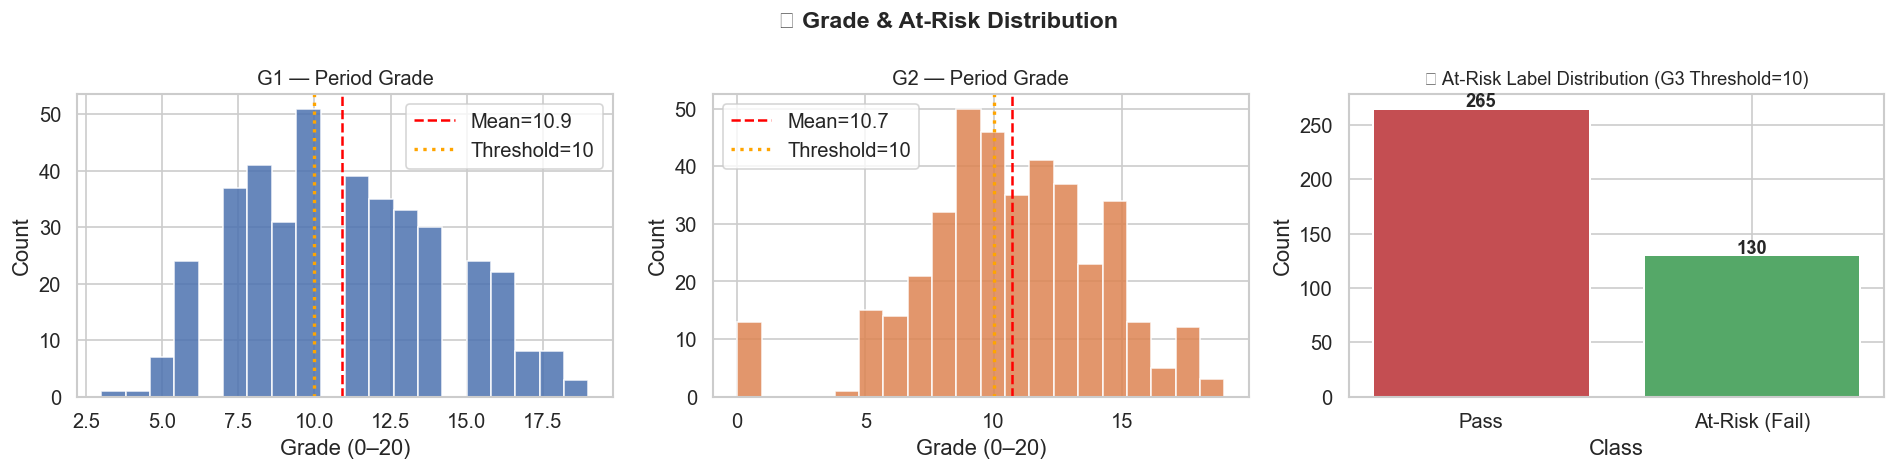


🎯 At-Risk Students (G3 < 10): 130 (32.9%)
✅ Pass Students (G3 ≥ 10)   : 265 (67.1%)


In [12]:
# ── Target Variable Distribution (at_risk) ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('📊 Grade & At-Risk Distribution', fontsize=14, fontweight='bold')

# Grade histograms for G1, G2, G3
for ax, col, color in zip(axes[:2], ['G1', 'G2'], PALETTE[:2]):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean={df[col].mean():.1f}')
    ax.axvline(10, color='orange', linestyle=':', linewidth=2, label='Threshold=10')
    ax.set_title(f'{col} — Period Grade', fontsize=12)
    ax.set_xlabel('Grade (0–20)')
    ax.set_ylabel('Count')
    ax.legend()

# At-risk bar chart
at_risk_counts = df['G3'].apply(lambda g: 'At-Risk (Fail)' if g < 10 else 'Pass').value_counts()
axes[2].bar(at_risk_counts.index, at_risk_counts.values,
            color=['#C44E52', '#55A868'], edgecolor='white', linewidth=1.2)
axes[2].set_title('🎯 At-Risk Label Distribution (G3 Threshold=10)', fontsize=11)
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')
for i, (cls, cnt) in enumerate(at_risk_counts.items()):
    axes[2].text(i, cnt + 2, str(cnt), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
n_at_risk = (df['G3'] < 10).sum()
print(f'\n🎯 At-Risk Students (G3 < 10): {n_at_risk} ({n_at_risk/len(df)*100:.1f}%)')
print(f'✅ Pass Students (G3 ≥ 10)   : {len(df)-n_at_risk} ({(len(df)-n_at_risk)/len(df)*100:.1f}%)')


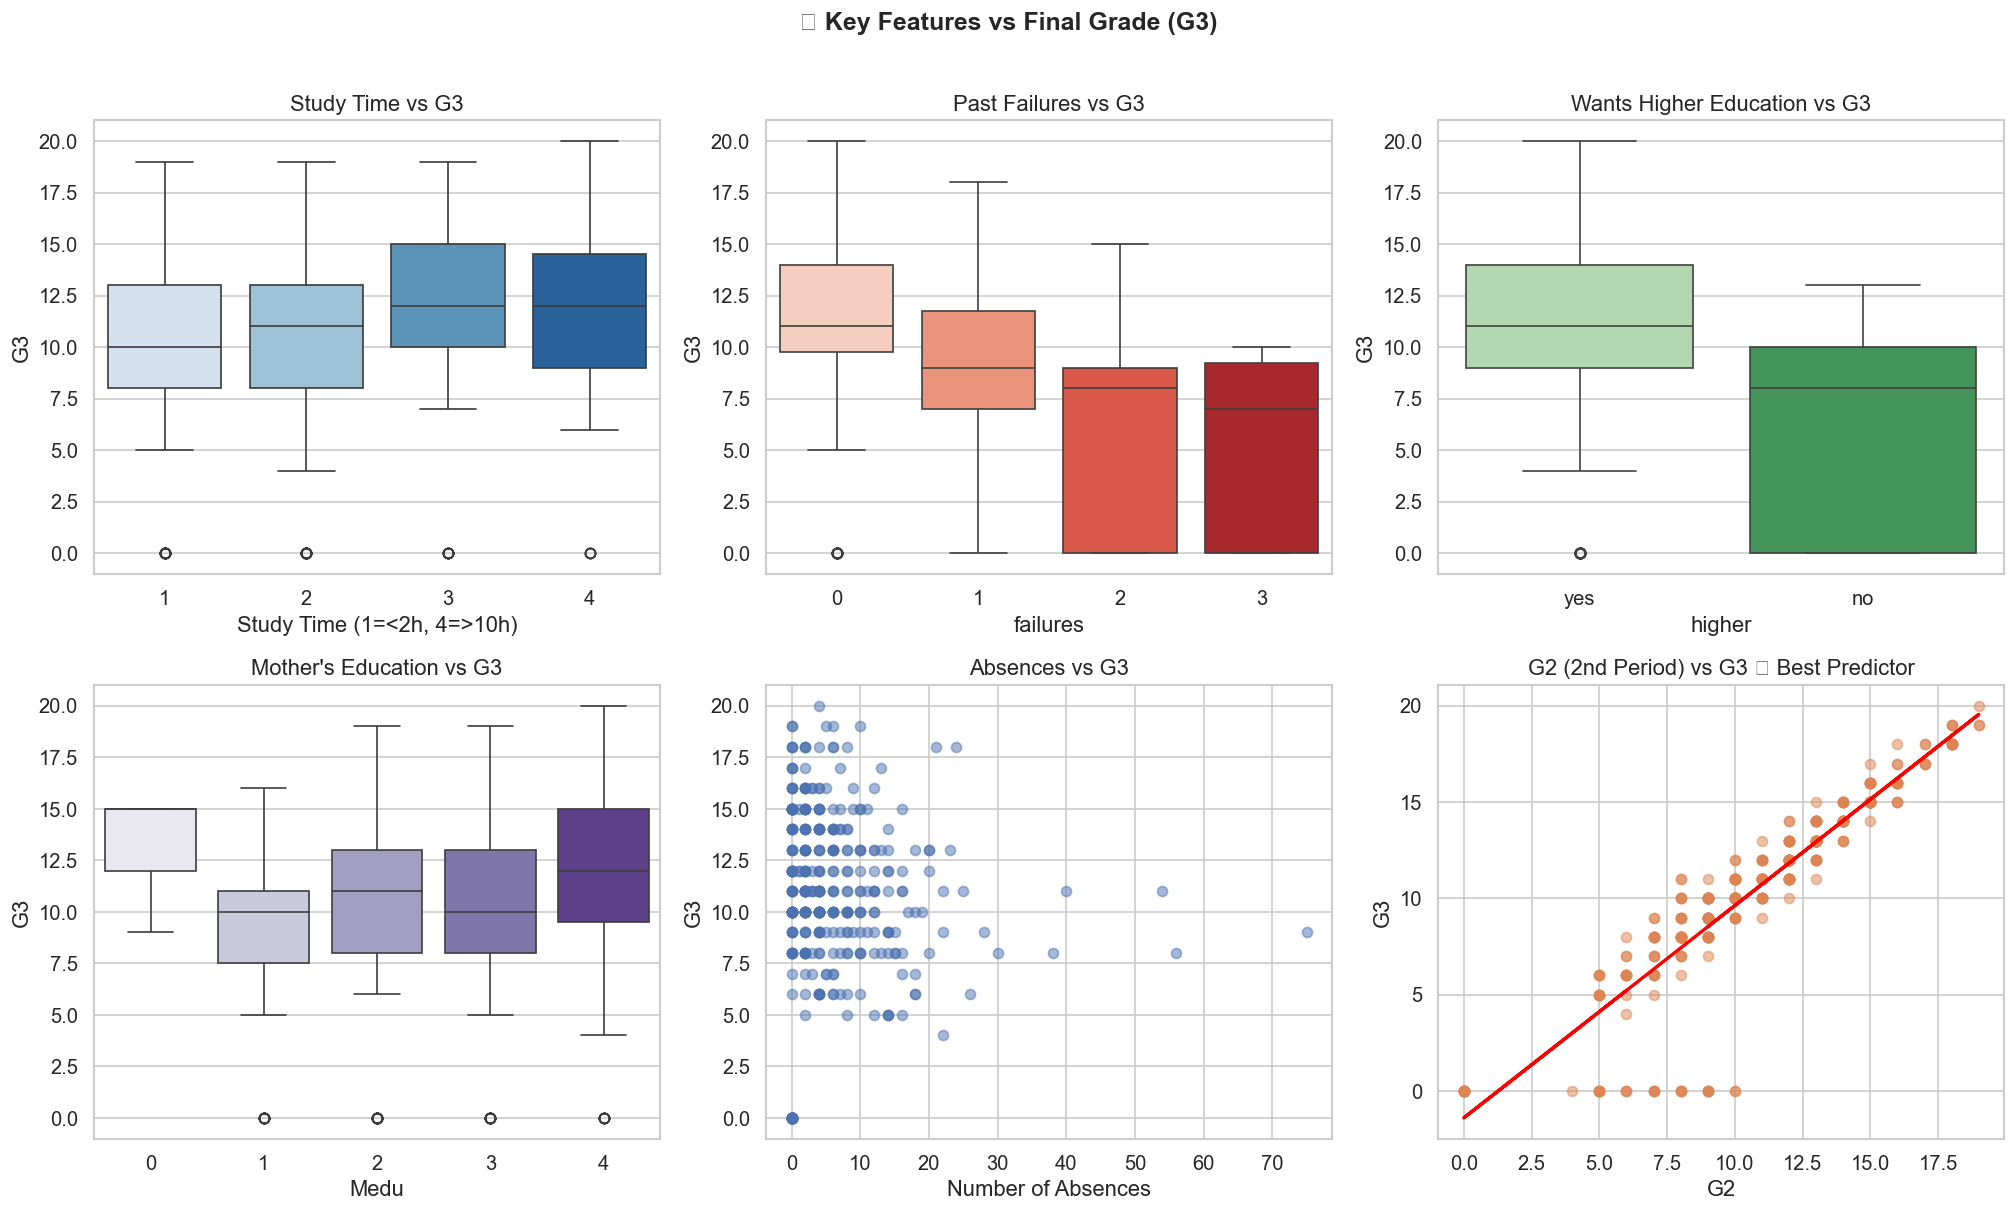

In [13]:
# ── Key Feature vs G3 Plots ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('🔑 Key Features vs Final Grade (G3)', fontsize=15, fontweight='bold', y=1.01)

# 1. Study time
sns.boxplot(data=df, x='studytime', y='G3', palette='Blues', ax=axes[0,0])
axes[0,0].set_title('Study Time vs G3')
axes[0,0].set_xlabel('Study Time (1=<2h, 4=>10h)')

# 2. Past failures
sns.boxplot(data=df, x='failures', y='G3', palette='Reds', ax=axes[0,1])
axes[0,1].set_title('Past Failures vs G3')

# 3. Higher education aspiration
sns.boxplot(data=df, x='higher', y='G3', palette='Greens', ax=axes[0,2])
axes[0,2].set_title('Wants Higher Education vs G3')

# 4. Parental education
sns.boxplot(data=df, x='Medu', y='G3', palette='Purples', ax=axes[1,0])
axes[1,0].set_title("Mother's Education vs G3")

# 5. Absences
axes[1,1].scatter(df['absences'], df['G3'], alpha=0.5, color=PALETTE[0])
axes[1,1].set_title('Absences vs G3')
axes[1,1].set_xlabel('Number of Absences')
axes[1,1].set_ylabel('G3')

# 6. G2 vs G3
axes[1,2].scatter(df['G2'], df['G3'], alpha=0.5, color=PALETTE[1])
m, b = np.polyfit(df['G2'], df['G3'], 1)
axes[1,2].plot(df['G2'], m*df['G2']+b, color='red', linewidth=2)
axes[1,2].set_title('G2 (2nd Period) vs G3 ✅ Best Predictor')
axes[1,2].set_xlabel('G2')
axes[1,2].set_ylabel('G3')

plt.tight_layout()
plt.show()

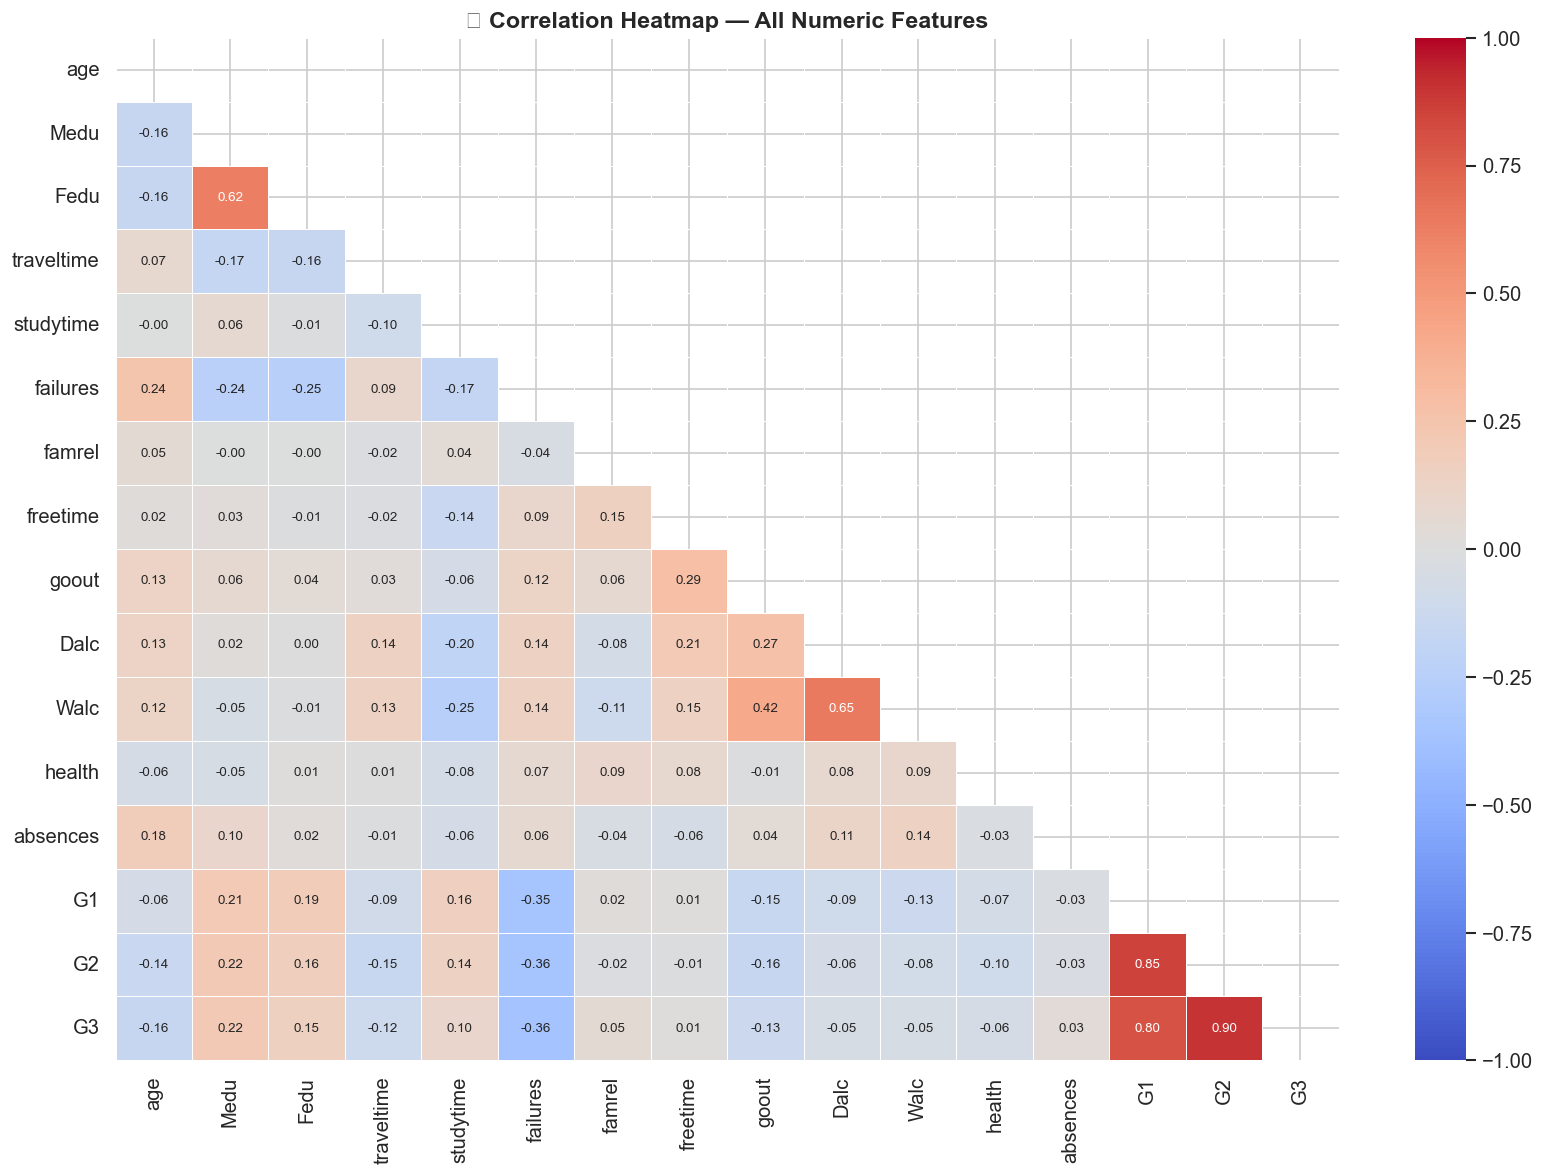


🔗 Top 10 Features Correlated with G3:
G2            0.904868
G1            0.801468
failures      0.360415
Medu          0.217147
age           0.161579
Fedu          0.152457
goout         0.132791
traveltime    0.117142
studytime     0.097820
health        0.061335


In [14]:
# ── Correlation Heatmap ───────────────────────────────────────────────
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, center=0,
            annot_kws={'size': 8})
plt.title('📈 Correlation Heatmap — All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with G3
print('\n🔗 Top 10 Features Correlated with G3:')
print(corr['G3'].abs().sort_values(ascending=False).drop('G3').head(10).to_string())

## ⚙️ Step 4: Data Preprocessing

In [15]:
# ── Identify Column Types for Pipeline ──────────────────────────────
df_processed = df.copy()

categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()
numerical_cols   = df_processed.select_dtypes(include='number').columns.tolist()
# Remove grade columns that shouldn't be in features
numerical_cols   = [c for c in numerical_cols if c not in ['G1', 'G2', 'G3']]

print(f'✅ Categorical columns ({len(categorical_cols)}): {categorical_cols}')
print(f'✅ Numerical columns  ({len(numerical_cols)}): {numerical_cols}')


✅ Categorical columns (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
✅ Numerical columns  (13): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [16]:
# ── Define At-Risk Classification Target ────────────────────────────
AT_RISK_THRESHOLD = 10
df_processed['at_risk'] = (df_processed['G3'] < AT_RISK_THRESHOLD).astype(int)

print(f'✅ At-Risk threshold: G3 < {AT_RISK_THRESHOLD}')
print(f'   Class 0 (Pass)    : {(df_processed["at_risk"]==0).sum()} students')
print(f'   Class 1 (At-Risk) : {(df_processed["at_risk"]==1).sum()} students')

# ── Define Features & Target (raw — pipeline handles encoding) ──────
TARGET   = 'at_risk'
DROP_COLS = [TARGET, 'G3', 'G1', 'G2']   # Drop grades to avoid leakage

X = df_processed.drop(columns=DROP_COLS)
y = df_processed[TARGET]

print(f'\n📐 Feature matrix shape: {X.shape}')
print(f'🎯 Target shape: {y.shape}')
print(f'📋 Features used ({X.shape[1]}): {list(X.columns)}')


✅ At-Risk threshold: G3 < 10
   Class 0 (Pass)    : 265 students
   Class 1 (At-Risk) : 130 students

📐 Feature matrix shape: (395, 30)
🎯 Target shape: (395,)
📋 Features used (30): ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


## 🛠️ Step 4b: Feature Engineering

Adding derived features to capture combined behavioral and support signals:
- **`total_alcohol`** = `Dalc` + `Walc` — combined alcohol exposure
- **`study_efficiency`** = `studytime / (failures + 1)` — how productive study time is relative to past failures
- **`support_score`** = `schoolsup` + `famsup` + `paid` — total support resources available to the student

In [45]:
# ── 🛠️ Feature Engineering ──────────────────────────────────────────
# Derived features added directly to df_processed (before pipeline)
# Pipeline will scale/encode them along with all other columns

# 1. Total Alcohol Consumption (weekday + weekend)
df_processed['total_alcohol'] = df_processed['Dalc'] + df_processed['Walc']

# 2. Study Efficiency (studytime relative to number of past failures)
df_processed['study_efficiency'] = df_processed['studytime'] / (df_processed['failures'] + 1)

# 3. Support Score (school + family support + paid classes)
df_processed['support_score'] = (
    df_processed['schoolsup'].map({'yes': 1, 'no': 0}) +
    df_processed['famsup'].map({'yes': 1, 'no': 0}) +
    df_processed['paid'].map({'yes': 1, 'no': 0})
)

# Update X to include new features (re-drop target cols)
X = df_processed.drop(columns=DROP_COLS + ['at_risk'], errors='ignore')

# Refresh column type lists to include engineered features
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols   = X.select_dtypes(include='number').columns.tolist()

print(' Feature Engineering Complete!')
print(f'   total_alcohol    : min={df_processed["total_alcohol"].min()}, max={df_processed["total_alcohol"].max()}, mean={df_processed["total_alcohol"].mean():.2f}')
print(f'   study_efficiency : min={df_processed["study_efficiency"].min():.2f}, max={df_processed["study_efficiency"].max():.2f}, mean={df_processed["study_efficiency"].mean():.2f}')
print(f'   support_score    : min={df_processed["support_score"].min()}, max={df_processed["support_score"].max()}, mean={df_processed["support_score"].mean():.2f}')
print(f'\n📐 Final feature matrix shape: {X.shape}')
print(f'   Categorical ({len(categorical_cols)}): {categorical_cols}')
print(f'   Numerical   ({len(numerical_cols)}): {numerical_cols}')


 Feature Engineering Complete!
   total_alcohol    : min=2, max=10, mean=3.77
   study_efficiency : min=0.25, max=4.00, mean=1.82
   support_score    : min=0, max=3, mean=1.20

📐 Final feature matrix shape: (395, 33)
   Categorical (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
   Numerical   (16): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'total_alcohol', 'study_efficiency', 'support_score']


## 📊 Step 4c: Improved Evaluation

Evaluation strategy:
- **Train/Test Split** — 80/20 stratified split
- **5-Fold Cross-Validation** — F1 score across folds
- **`classification_report`** — per-class precision, recall, F1

In [20]:
# ── Step 4c: Improved Evaluation ────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# ── 1. Train/Test Split ──────────────────────────────────────────────
#  1 : Use X and y from Step 4b — NOT df[top_features] (undefined)
#           X is already feature-engineered and has no grade columns
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train samples : {len(X_tr)}  |  Test samples : {len(X_te)}')
print(f'Train class dist: {dict(y_tr.value_counts().sort_index())}')
print(f'Test  class dist: {dict(y_te.value_counts().sort_index())}')

# ── 2. Build evaluation pipeline with proper preprocessing ──────────
#  2: Add ColumnTransformer — StandardScaler alone can't handle
#           categorical string columns like 'school', 'sex', etc.
eval_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),                                        numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ],
    remainder='drop'
)

eval_pipeline = Pipeline([
    ('preprocessor', eval_preprocessor),
    ('clf',          LogisticRegression(max_iter=1000, random_state=42))
])

# ── 3. 5-Fold Cross-Validation ───────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(eval_pipeline, X_tr, y_tr, cv=skf, scoring='f1')

print('\n' + '='*55)
print('5-Fold Stratified Cross-Validation (F1 Score)')
print('='*55)
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'  Mean F1 : {cv_scores.mean():.4f}')
print(f'  Std  F1 : {cv_scores.std():.4f}')

# ── 4. Fit on train, evaluate on test ───────────────────────────────
eval_pipeline.fit(X_tr, y_tr)
y_pred_eval = eval_pipeline.predict(X_te)

print('\n' + '='*55)
print('Classification Report (Test Set)')
print('='*55)
print(classification_report(
    y_te, y_pred_eval,
    target_names=['Pass (0)', 'At-Risk (1)'],
    digits=4
))

Train samples : 316  |  Test samples : 79
Train class dist: {0: np.int64(212), 1: np.int64(104)}
Test  class dist: {0: np.int64(53), 1: np.int64(26)}

5-Fold Stratified Cross-Validation (F1 Score)
  Fold 1: 0.3448
  Fold 2: 0.4286
  Fold 3: 0.4667
  Fold 4: 0.5263
  Fold 5: 0.2632
  Mean F1 : 0.4059
  Std  F1 : 0.0925

Classification Report (Test Set)
              precision    recall  f1-score   support

    Pass (0)     0.7231    0.8868    0.7966        53
 At-Risk (1)     0.5714    0.3077    0.4000        26

    accuracy                         0.6962        79
   macro avg     0.6473    0.5972    0.5983        79
weighted avg     0.6732    0.6962    0.6661        79



## 🔧 Step 5: Build sklearn Pipeline

In [21]:
# ── ColumnTransformer: encode categoricals, scale numericals ─────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),                                    numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ],
    remainder='drop'
)

# ── Train / Test Split (on raw X — pipeline handles transforms) ───────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'📊 Train : {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'🏷️  Train class dist: {dict(y_train.value_counts().sort_index())}')
print(f'🏷️  Test  class dist: {dict(y_test.value_counts().sort_index())}')


📊 Train : 316 samples | Test: 79 samples
🏷️  Train class dist: {0: np.int64(212), 1: np.int64(104)}
🏷️  Test  class dist: {0: np.int64(53), 1: np.int64(26)}


In [22]:
# ── Build one Pipeline per model ────────────────────────────────────
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                            min_samples_leaf=5, random_state=42))
])

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(n_estimators=200, max_depth=8,
                                            min_samples_split=5, min_samples_leaf=3,
                                            random_state=42, n_jobs=-1))
])

pipeline_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                max_depth=4, random_state=42))
])

pipelines = {
    'Logistic Regression' : pipeline_lr,
    'Decision Tree'        : pipeline_dt,
    'Random Forest'        : pipeline_rf,
    'Gradient Boosting'    : pipeline_gb,
}

print('✅ Pipelines built:')
for name, pipe in pipelines.items():
    steps = ' → '.join([s for s, _ in pipe.steps])
    print(f'   {name:<22}: {steps}')


✅ Pipelines built:
   Logistic Regression   : preprocessor → classifier
   Decision Tree         : preprocessor → classifier
   Random Forest         : preprocessor → classifier
   Gradient Boosting     : preprocessor → classifier


## 🔧 Step 5b: Hyperparameter Tuning — RandomizedSearchCV (Random Forest)

In [23]:
# ── Step 5b: RandomizedSearchCV for Random Forest ───────────────────
from sklearn.model_selection import RandomizedSearchCV

# Small search space
param_dist = {
    'classifier__n_estimators':   [100, 200, 300],
    'classifier__max_depth':       [4, 6, 8, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf':  [1, 3, 5],
}

random_search = RandomizedSearchCV(
    estimator   = pipeline_rf,
    param_distributions = param_dist,
    n_iter      = 10,
    cv          = 5,
    scoring     = 'f1',
    random_state= 42,
    n_jobs      = -1,
    verbose     = 1
)

random_search.fit(X_train, y_train)

print('Best Params :', random_search.best_params_)
print(f'Best CV F1  : {random_search.best_score_:.4f}')

# Best model — drop-in replacement for pipeline_rf
best_rf = random_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score
print('\nClassification Report — Tuned Random Forest')
print('='*50)
print(classification_report(y_test, y_pred_best_rf,
                             target_names=['Pass (0)', 'At-Risk (1)'],
                             digits=4))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_best_rf):.4f}')


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params : {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None}
Best CV F1  : 0.4024

Classification Report — Tuned Random Forest
              precision    recall  f1-score   support

    Pass (0)     0.7206    0.9245    0.8099        53
 At-Risk (1)     0.6364    0.2692    0.3784        26

    accuracy                         0.7089        79
   macro avg     0.6785    0.5969    0.5941        79
weighted avg     0.6929    0.7089    0.6679        79

ROC-AUC : 0.6996


## ✂️ Step 6: Pipeline Overview

In [24]:
# ── Pipeline Structure Summary ───────────────────────────────────────
print('Pipeline Architecture')
print('─' * 55)
print(f'  Step 1 │ ColumnTransformer')
print(f'         │   • StandardScaler      → {len(numerical_cols)} numerical features')
print(f'         │   • OneHotEncoder       → {len(categorical_cols)} categorical features')
print(f'  Step 2 │ Classifier (swapped per model)')
print('─' * 55)

# Fit one pipeline to show output shape
pipeline_lr.fit(X_train, y_train)
X_transformed = pipeline_lr[:-1].transform(X_train)
print(f'\n📐 Input shape  : {X_train.shape}')
print(f'📐 After preprocessing: {X_transformed.shape}')
print(f'   (StandardScaler: {len(numerical_cols)} cols  +  OneHotEncoder expanded: {X_transformed.shape[1] - len(numerical_cols)} cols)')


Pipeline Architecture
───────────────────────────────────────────────────────
  Step 1 │ ColumnTransformer
         │   • StandardScaler      → 16 numerical features
         │   • OneHotEncoder       → 17 categorical features
  Step 2 │ Classifier (swapped per model)
───────────────────────────────────────────────────────

📐 Input shape  : (316, 33)
📐 After preprocessing: (316, 59)
   (StandardScaler: 16 cols  +  OneHotEncoder expanded: 43 cols)


## 💾 Step 6b: Model Saving — joblib

In [25]:
# ── Step 6b: Save trained pipeline with joblib ──────────────────────
import joblib
import os

MODEL_PATH = 'model.pkl'

# Save best tuned RF pipeline (falls back to pipeline_rf if tuning wasn't run)
model_to_save = best_rf if 'best_rf' in dir() else pipeline_rf

joblib.dump(model_to_save, MODEL_PATH)
print(f'Model saved  → {MODEL_PATH}  ({os.path.getsize(MODEL_PATH)/1024:.1f} KB)')

# ── Verify: reload and predict ──────────────────────────────────────
loaded_model = joblib.load(MODEL_PATH)
sample_pred  = loaded_model.predict(X_test[:5])
print(f'Reload check → predictions on first 5 test samples: {sample_pred}')


Model saved  → model.pkl  (3711.6 KB)
Reload check → predictions on first 5 test samples: [1 0 0 0 0]


## 🔥 Additional: MLflow Experiment Tracking

In [28]:
# ── Bonus: MLflow Tracking ────────────────────────────────────────────
try:
    import mlflow
    import mlflow.sklearn
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "mlflow==2.13.2", "-q"])
    import mlflow
    import mlflow.sklearn

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)  # suppress INFO/WARNING logs

from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, precision_score, recall_score

# ✅ File-based tracking URI — no SQLite/DB migration needed
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("student_at_risk")

with mlflow.start_run(run_name="RandomForest_tuned"):

    # ── Log params ───────────────────────────────────────────────────
    best_params = random_search.best_params_
    mlflow.log_param("n_estimators",      best_params.get("classifier__n_estimators"))
    mlflow.log_param("max_depth",         best_params.get("classifier__max_depth"))
    mlflow.log_param("min_samples_split", best_params.get("classifier__min_samples_split"))
    mlflow.log_param("min_samples_leaf",  best_params.get("classifier__min_samples_leaf"))
    mlflow.log_param("cv_folds",          5)
    mlflow.log_param("test_size",         0.2)

    # ── Log metrics ──────────────────────────────────────────────────
    mlflow.log_metric("cv_f1_mean", round(random_search.best_score_, 4))
    mlflow.log_metric("accuracy",   round(accuracy_score (y_test, y_pred_best_rf), 4))
    mlflow.log_metric("precision",  round(precision_score(y_test, y_pred_best_rf, zero_division=0), 4))
    mlflow.log_metric("recall",     round(recall_score   (y_test, y_pred_best_rf, zero_division=0), 4))
    mlflow.log_metric("f1",         round(f1_score       (y_test, y_pred_best_rf, zero_division=0), 4))
    mlflow.log_metric("roc_auc",    round(roc_auc_score  (y_test, y_prob_best_rf), 4))

    # ── Log model ────────────────────────────────────────────────────
    mlflow.sklearn.log_model(best_rf, artifact_path="model")

    run_id = mlflow.active_run().info.run_id

print(f"✅ MLflow run logged  |  run_id: {run_id}")
print(f"   Params  : {best_params}")
print(f"   CV F1   : {random_search.best_score_:.4f}")
print(f"   Test F1 : {f1_score(y_test, y_pred_best_rf):.4f}")
print(f"   ROC-AUC : {roc_auc_score(y_test, y_prob_best_rf):.4f}")
print()
print("▶  View UI: mlflow ui  →  http://localhost:5000")

✅ MLflow run logged  |  run_id: 60dc03cf862647c280676fd387f817e6
   Params  : {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None}
   CV F1   : 0.4024
   Test F1 : 0.3784
   ROC-AUC : 0.6996

▶  View UI: mlflow ui  →  http://localhost:5000


## 🚀 Step 7b: FastAPI Deployment

In [29]:
# ── Step 7b: FastAPI app — save as app.py ───────────────────────────
app_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, numpy as np

app   = FastAPI()
model = joblib.load("model.pkl")

class StudentInput(BaseModel):
    studytime: int
    failures:  int
    absences:  int

@app.post("/predict")
def predict(data: StudentInput):
    X = np.array([[data.studytime, data.failures, data.absences]])
    pred  = model.predict(X)[0]
    proba = model.predict_proba(X)[0][1]
    return {"at_risk": int(pred), "probability": round(float(proba), 4)}
'''

with open('app.py', 'w') as f:
    f.write(app_code.strip())

print('app.py saved.')
print('Run with: uvicorn app:app --reload')


app.py saved.
Run with: uvicorn app:app --reload


## 🤖 Step 7: Model Training via Pipeline

In [30]:
# ════════════════════════════════════════════════════════════════════
# MODEL 1 — LOGISTIC REGRESSION PIPELINE
# ════════════════════════════════════════════════════════════════════
print('=' * 55)
print('🔵 MODEL 1: LOGISTIC REGRESSION')
print('=' * 55)

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]

# Coefficients (post-transform feature names)
lr_model   = pipeline_lr.named_steps['classifier']
ohe_cols   = pipeline_lr.named_steps['preprocessor']                          .named_transformers_['cat']                          .get_feature_names_out(categorical_cols).tolist()
all_feat_names = numerical_cols + ohe_cols

coef_df = pd.DataFrame({'Feature': all_feat_names, 'Coefficient': lr_model.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print('\n📋 Top 10 Feature Coefficients (log-odds):')
print(coef_df.head(10).to_string(index=False))


🔵 MODEL 1: LOGISTIC REGRESSION

📋 Top 10 Feature Coefficients (log-odds):
      Feature  Coefficient
     failures     0.557465
reason_course     0.496710
Mjob_services    -0.470765
        goout     0.466393
 Mjob_teacher     0.453843
Fjob_services     0.411325
 reason_other    -0.345554
    higher_no     0.308426
   higher_yes    -0.307506
    Pstatus_T     0.275712


In [31]:
# ════════════════════════════════════════════════════════════════════
# MODEL 2 — DECISION TREE PIPELINE
# ════════════════════════════════════════════════════════════════════
print('=' * 55)
print('🌳 MODEL 2: DECISION TREE CLASSIFIER')
print('=' * 55)

pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)
y_prob_dt = pipeline_dt.predict_proba(X_test)[:, 1]

dt_model = pipeline_dt.named_steps['classifier']
print(f'Tree Depth    : {dt_model.get_depth()}')
print(f'Number of Leaves: {dt_model.get_n_leaves()}')


🌳 MODEL 2: DECISION TREE CLASSIFIER
Tree Depth    : 5
Number of Leaves: 15


In [32]:
# ════════════════════════════════════════════════════════════════════
# MODEL 3 — RANDOM FOREST PIPELINE
# ════════════════════════════════════════════════════════════════════
print('=' * 55)
print('🌲 MODEL 3: RANDOM FOREST CLASSIFIER')
print('=' * 55)

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]

rf_model = pipeline_rf.named_steps['classifier']
print(f'Number of Trees : {rf_model.n_estimators}')
print(f'Max Depth       : {rf_model.max_depth}')


🌲 MODEL 3: RANDOM FOREST CLASSIFIER
Number of Trees : 200
Max Depth       : 8


In [33]:
# ════════════════════════════════════════════════════════════════════
# BONUS MODEL 4 — GRADIENT BOOSTING PIPELINE
# ════════════════════════════════════════════════════════════════════
print('=' * 55)
print('🚀 BONUS MODEL 4: GRADIENT BOOSTING CLASSIFIER')
print('=' * 55)

pipeline_gb.fit(X_train, y_train)
y_pred_gb = pipeline_gb.predict(X_test)
y_prob_gb = pipeline_gb.predict_proba(X_test)[:, 1]

print('✅ All 4 pipeline models trained successfully!')


🚀 BONUS MODEL 4: GRADIENT BOOSTING CLASSIFIER
✅ All 4 pipeline models trained successfully!


## 📊 Step 8: Improved Evaluation

Evaluation strategy:
- **Train/Test split** — 80/20 stratified (done in Step 5)
- **5-Fold Cross-Validation** — F1 on training set per model
- **`classification_report`** — per-class precision, recall, F1 for every model

In [34]:
# ── Evaluation Function ──────────────────────────────────────────────
def evaluate_model(name, y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob)
    return {'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
            'Recall': round(rec, 4), 'F1 Score': round(f1, 4), 'ROC-AUC': round(auc, 4)}

all_preds = {
    'Logistic Regression' : (y_pred_lr, y_prob_lr),
    'Decision Tree'        : (y_pred_dt, y_prob_dt),
    'Random Forest'        : (y_pred_rf, y_prob_rf),
    'Gradient Boosting'    : (y_pred_gb, y_prob_gb),
}

results = [evaluate_model(name, y_test, yp, ypr) for name, (yp, ypr) in all_preds.items()]
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.index += 1

print('=' * 75)
print('📋 TRAIN / TEST SPLIT EVALUATION SUMMARY  (80 % train | 20 % test)')
print('=' * 75)
print(results_df.to_string())
print(f'\n🏆 Best Model : {results_df.iloc[0]["Model"]}  '
      f'| ROC-AUC: {results_df.iloc[0]["ROC-AUC"]}  '
      f'| F1: {results_df.iloc[0]["F1 Score"]}')


📋 TRAIN / TEST SPLIT EVALUATION SUMMARY  (80 % train | 20 % test)
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
1        Random Forest    0.7468     0.8000  0.3077    0.4444   0.7184
2  Logistic Regression    0.6962     0.5714  0.3077    0.4000   0.7170
3    Gradient Boosting    0.7089     0.6000  0.3462    0.4390   0.6814
4        Decision Tree    0.6835     0.5294  0.3462    0.4186   0.6724

🏆 Best Model : Random Forest  | ROC-AUC: 0.7184  | F1: 0.4444


In [35]:
# ── 5-Fold Cross-Validation ──────────────────────────────────────────
print('📊 5-Fold Cross-Validation  (scoring = F1, fitted on X_train)')
print('=' * 75)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression' : pipeline_lr,
    'Decision Tree'        : pipeline_dt,
    'Random Forest'        : pipeline_rf,
    'Gradient Boosting'    : pipeline_gb,
}

cv_results = {}
cv_summary = []
for name, pipe in models_cv.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='f1')
    cv_results[name] = scores
    cv_summary.append({'Model': name,
                       'CV Mean F1': round(scores.mean(), 4),
                       'CV Std':     round(scores.std(),  4),
                       'Fold Scores': np.round(scores, 3).tolist()})
    print(f'  {name:<22}: Mean={scores.mean():.4f} | Std={scores.std():.4f} | '
          f'Folds={np.round(scores, 3)}')

cv_df = pd.DataFrame(cv_summary).sort_values('CV Mean F1', ascending=False).reset_index(drop=True)
cv_df.index += 1
print()
print(cv_df[['Model', 'CV Mean F1', 'CV Std']].to_string())


📊 5-Fold Cross-Validation  (scoring = F1, fitted on X_train)
  Logistic Regression   : Mean=0.3706 | Std=0.0850 | Folds=[0.235 0.323 0.41  0.4   0.485]
  Decision Tree         : Mean=0.3625 | Std=0.0772 | Folds=[0.345 0.429 0.323 0.25  0.467]
  Random Forest         : Mean=0.3551 | Std=0.1085 | Folds=[0.308 0.308 0.286 0.303 0.571]
  Gradient Boosting     : Mean=0.4285 | Std=0.0446 | Folds=[0.485 0.353 0.444 0.45  0.41 ]

                 Model  CV Mean F1  CV Std
1    Gradient Boosting      0.4285  0.0446
2  Logistic Regression      0.3706  0.0850
3        Decision Tree      0.3625  0.0772
4        Random Forest      0.3551  0.1085


In [36]:
# ── Classification Report — All Models ───────────────────────────────
print('📋 CLASSIFICATION REPORT — ALL MODELS')
print('(Precision / Recall / F1 per class on held-out test set)')

for name, (y_pred, _) in all_preds.items():
    print()
    print('─' * 55)
    print(f'  {name}')
    print('─' * 55)
    print(classification_report(y_test, y_pred,
                                 target_names=['Pass (0)', 'At-Risk (1)'],
                                 digits=4))


📋 CLASSIFICATION REPORT — ALL MODELS
(Precision / Recall / F1 per class on held-out test set)

───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Pass (0)     0.7231    0.8868    0.7966        53
 At-Risk (1)     0.5714    0.3077    0.4000        26

    accuracy                         0.6962        79
   macro avg     0.6473    0.5972    0.5983        79
weighted avg     0.6732    0.6962    0.6661        79


───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Pass (0)     0.7258    0.8491    0.7826        53
 At-Risk (1)     0.5294    0.3462    0.4186        26

    accuracy                         0.6835        79
   macro avg     0.6276    0.5976    0.6006        79
weighted avg     0.6612    0.6835    0.6628

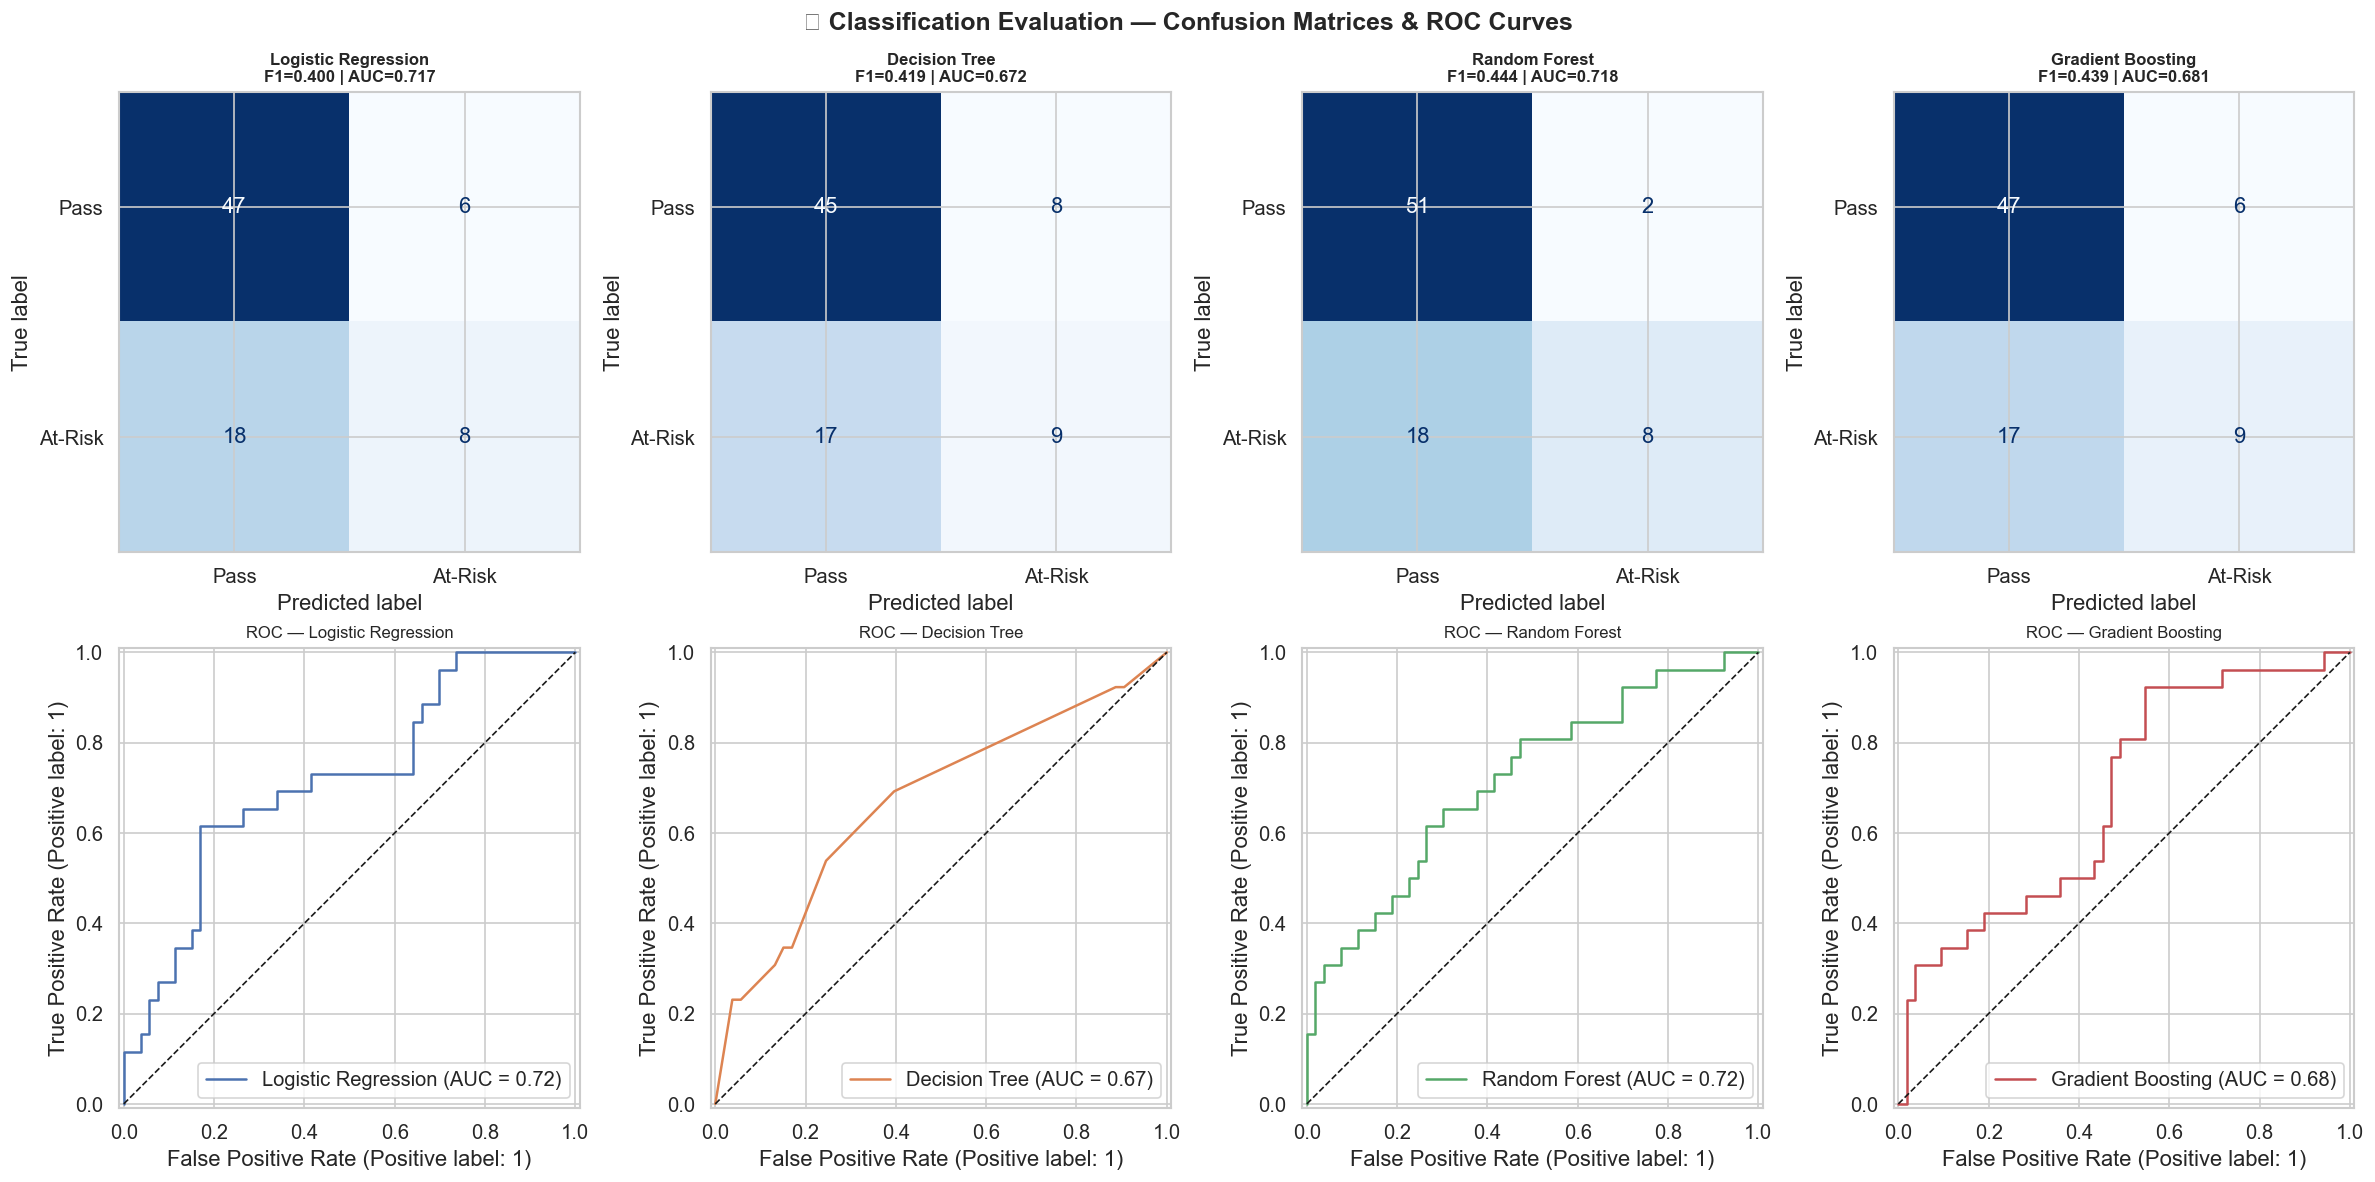

In [37]:
# ── Confusion Matrices & ROC Curves ──────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('🔍 Classification Evaluation — Confusion Matrices & ROC Curves',
             fontsize=15, fontweight='bold')

model_info = [
    ('Logistic Regression', y_pred_lr, y_prob_lr, PALETTE[0]),
    ('Decision Tree',       y_pred_dt, y_prob_dt, PALETTE[1]),
    ('Random Forest',       y_pred_rf, y_prob_rf, PALETTE[2]),
    ('Gradient Boosting',   y_pred_gb, y_prob_gb, PALETTE[3]),
]

for i, (name, y_pred, y_prob, color) in enumerate(model_info):
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Row 0: Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Pass', 'At-Risk'])
    disp.plot(ax=axes[0, i], colorbar=False, cmap='Blues')
    axes[0, i].set_title(f'{name}\nF1={f1:.3f} | AUC={auc:.3f}', fontsize=10, fontweight='bold')

    # Row 1: ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1, i],
                                     color=color, name=name)
    axes[1, i].set_title(f'ROC — {name}', fontsize=10)
    axes[1, i].plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.tight_layout()
plt.show()


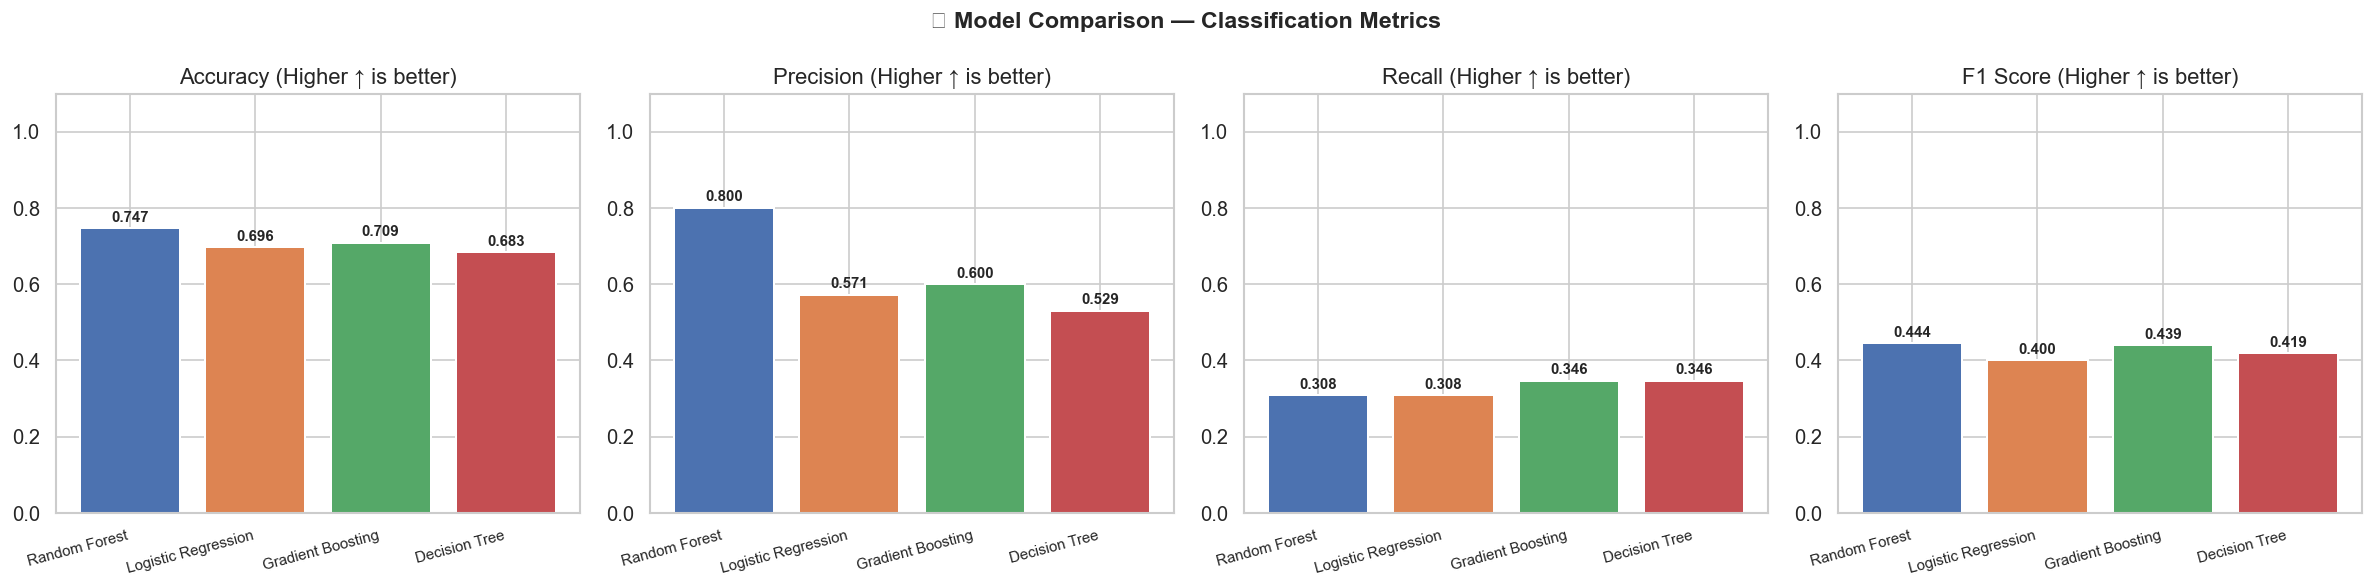

In [38]:
# ── Classification Metrics Bar Chart ──────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('📊 Model Comparison — Classification Metrics', fontsize=14, fontweight='bold')

models_names = results_df['Model'].tolist()
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for ax, metric in zip(axes, metrics):
    vals = results_df[metric].tolist()
    bars = ax.bar(models_names, vals, color=PALETTE[:4], edgecolor='white', linewidth=1.2)
    ax.set_title(f'{metric} (Higher ↑ is better)')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(models_names, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


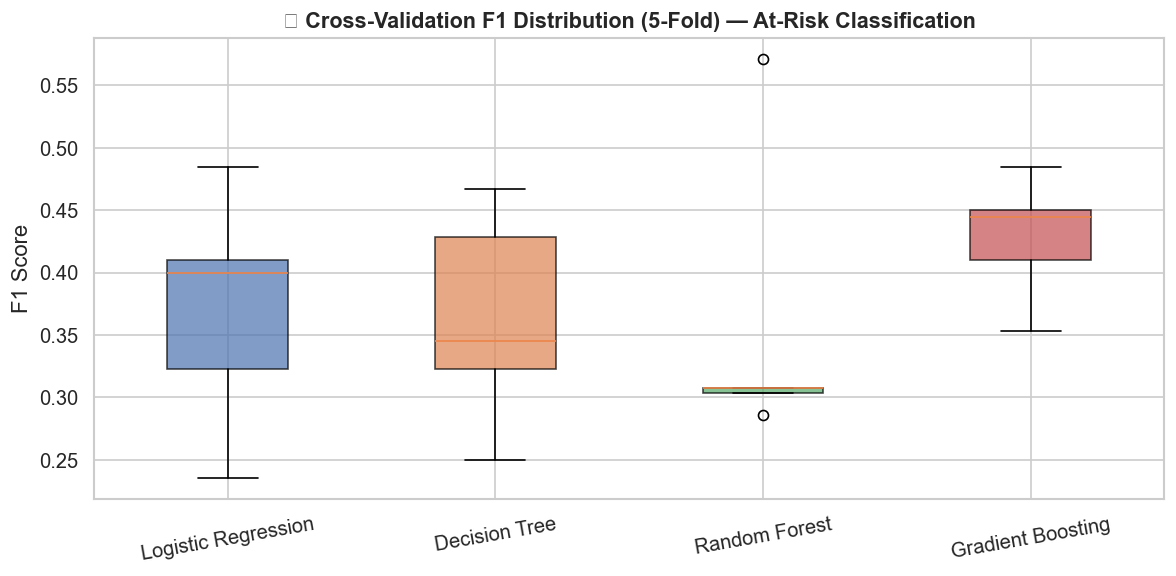

In [39]:
# ── CV F1 Score Boxplot ───────────────────────────────────────────────
plt.figure(figsize=(10, 5))
cv_data = [cv_results[m] for m in cv_results]
bp = plt.boxplot(cv_data, labels=list(cv_results.keys()), patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.title('📦 Cross-Validation F1 Distribution (5-Fold) — At-Risk Classification',
          fontsize=13, fontweight='bold')
plt.ylabel('F1 Score')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 🌿 Step 9: Feature Importance (Random Forest)

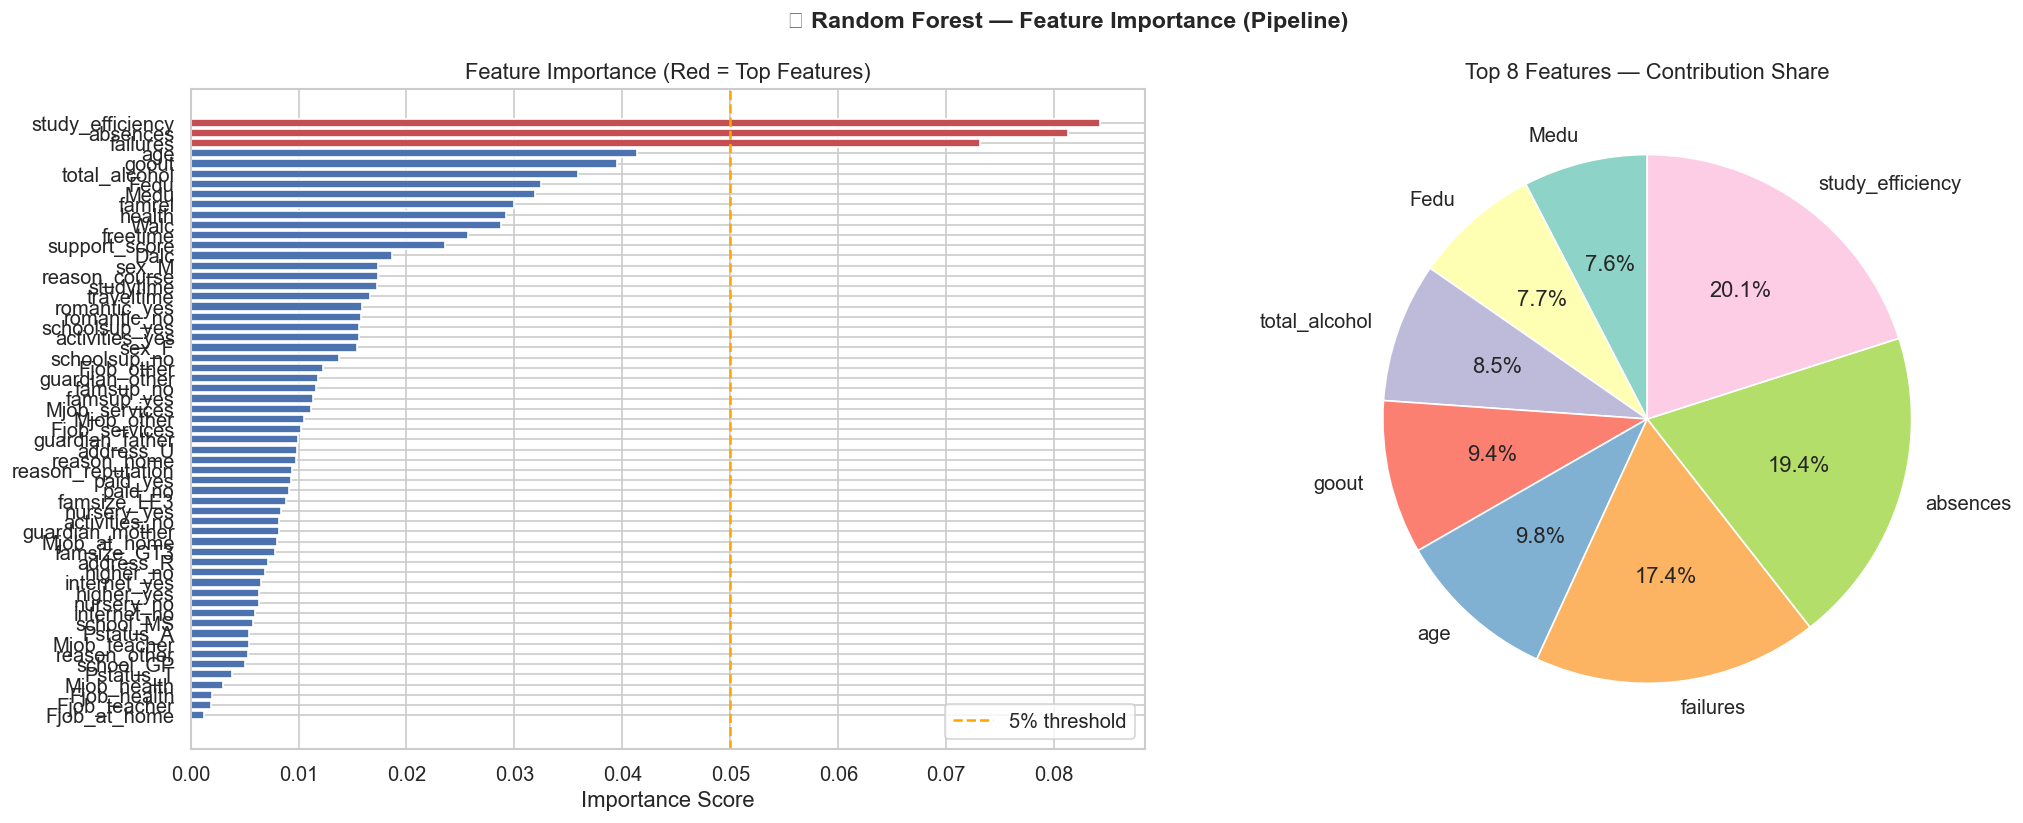

In [40]:
# ── Random Forest Feature Importance (via Pipeline) ──────────────────
rf_model   = pipeline_rf.named_steps['classifier']
ohe_cols   = pipeline_rf.named_steps['preprocessor']                           .named_transformers_['cat']                           .get_feature_names_out(categorical_cols).tolist()
all_feat_names = numerical_cols + ohe_cols

fi = pd.DataFrame({'Feature': all_feat_names, 'Importance': rf_model.feature_importances_})
fi = fi.sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🌲 Random Forest — Feature Importance (Pipeline)', fontsize=14, fontweight='bold')

colors = ['#c44e52' if imp > 0.05 else '#4c72b0' for imp in fi['Importance']]
axes[0].barh(fi['Feature'], fi['Importance'], color=colors)
axes[0].axvline(0.05, color='orange', linestyle='--', label='5% threshold')
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Feature Importance (Red = Top Features)')
axes[0].legend()

top8 = fi.tail(8)
axes[1].pie(top8['Importance'], labels=top8['Feature'], autopct='%1.1f%%',
            colors=sns.color_palette('Set3', 8), startangle=90)
axes[1].set_title('Top 8 Features — Contribution Share')

plt.tight_layout()
plt.show()


## 🌳 Step 10: Decision Tree Visualization

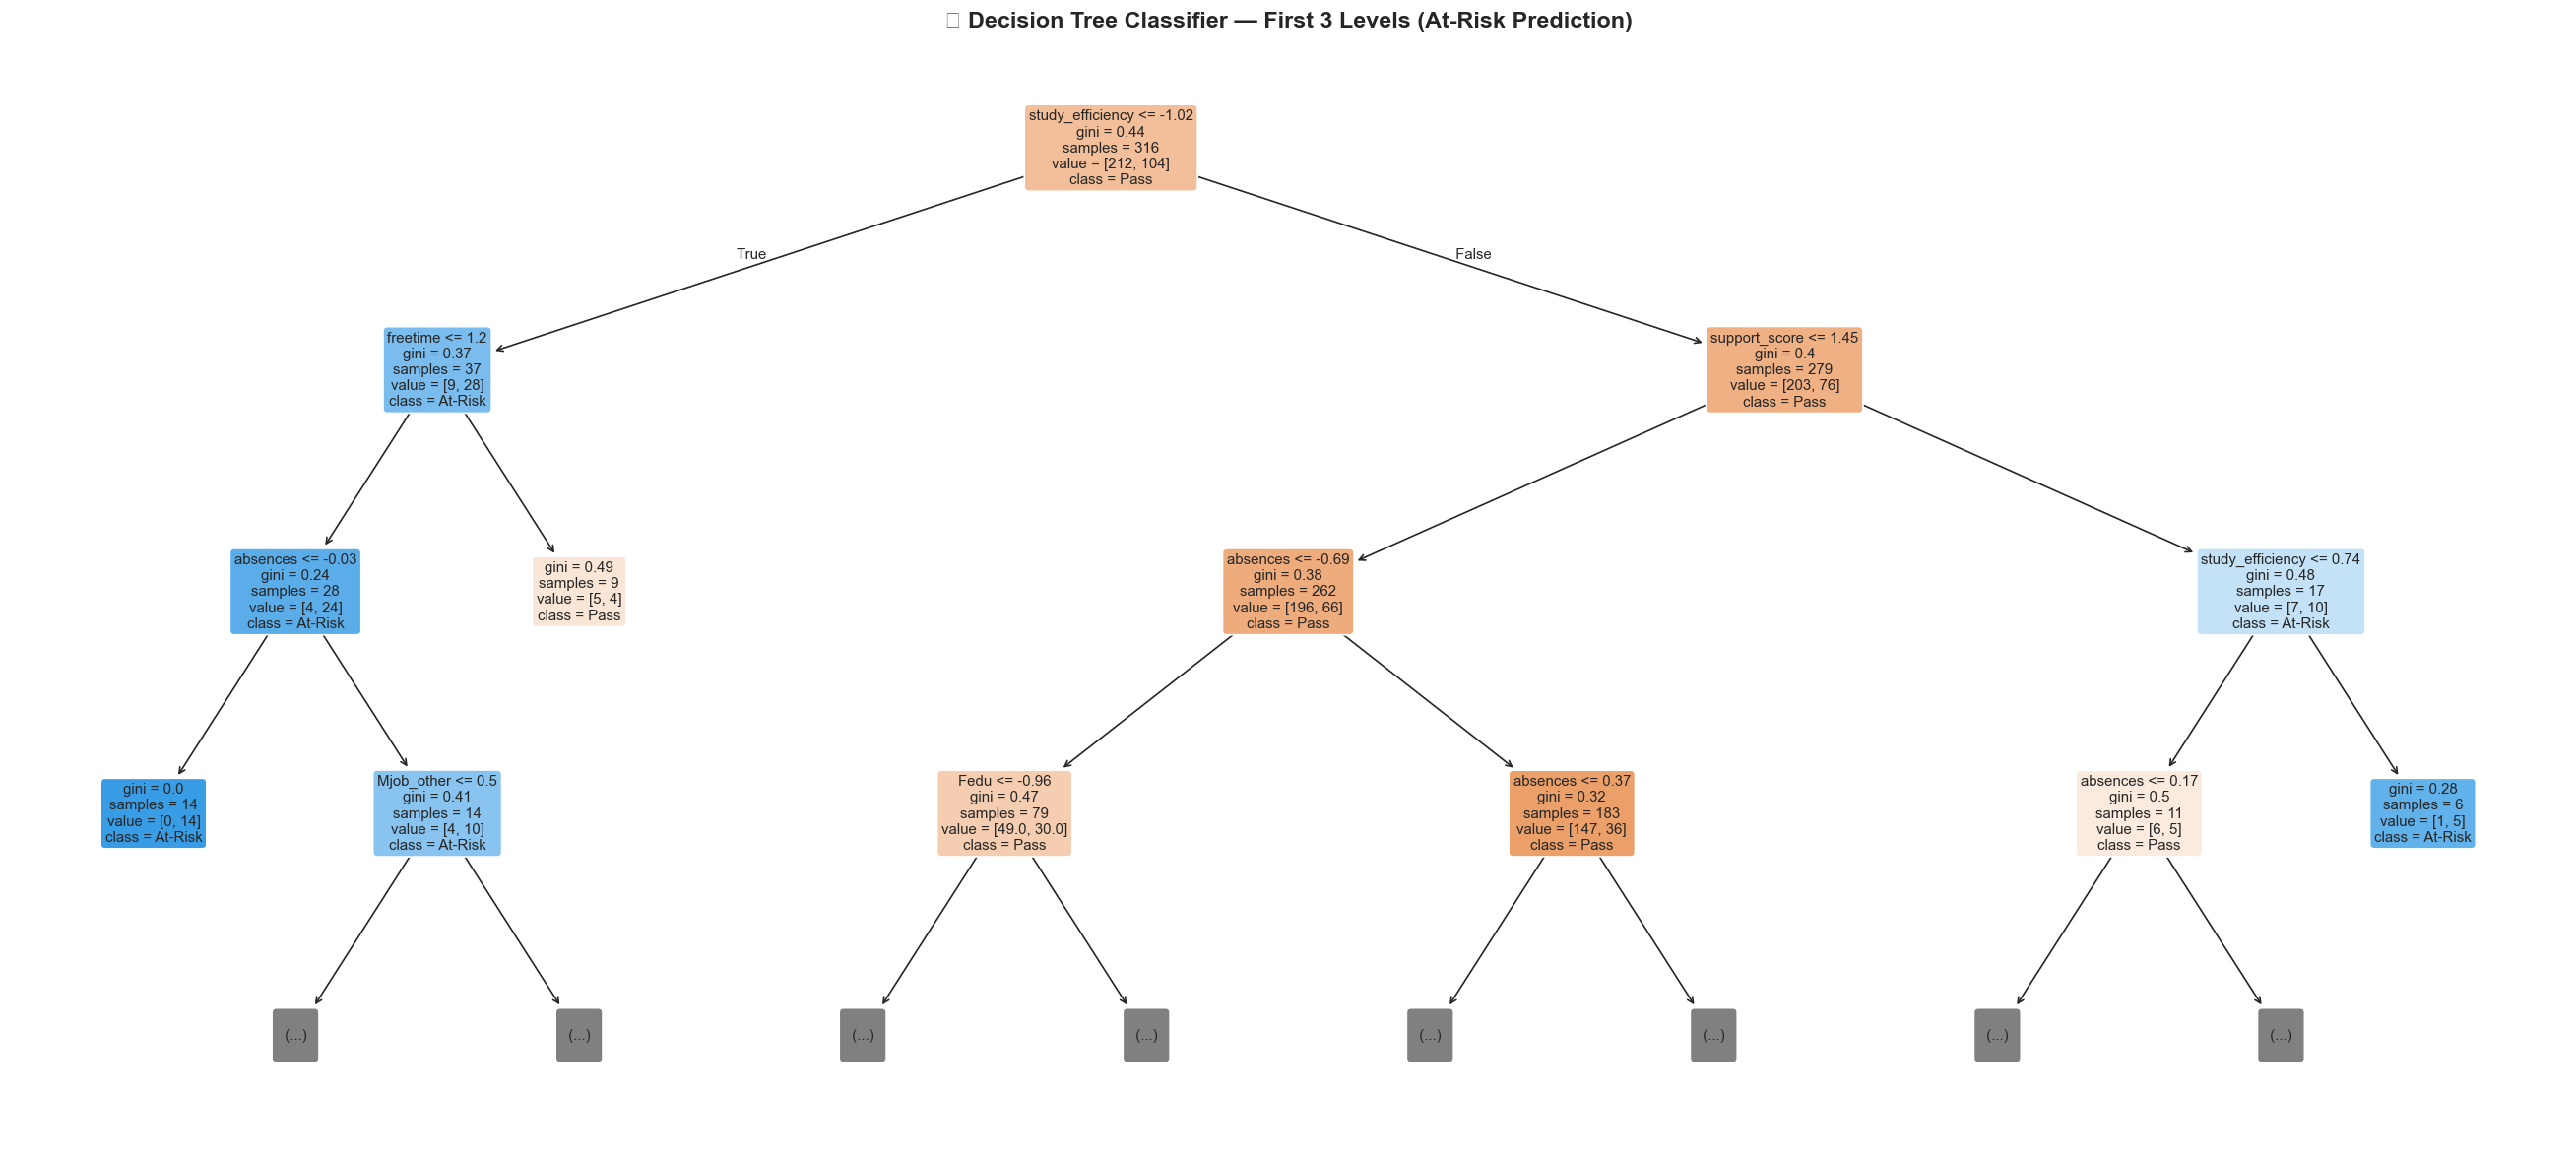

In [41]:
# ── Decision Tree Classifier Plot (via Pipeline) ──────────────────────
ohe_cols_dt = pipeline_dt.named_steps['preprocessor']                            .named_transformers_['cat']                            .get_feature_names_out(categorical_cols).tolist()
dt_feat_names = numerical_cols + ohe_cols_dt

plt.figure(figsize=(22, 10))
plot_tree(pipeline_dt.named_steps['classifier'],
          feature_names=dt_feat_names,
          class_names=['Pass', 'At-Risk'],
          max_depth=3, filled=True, rounded=True, fontsize=9,
          impurity=True, precision=2)
plt.title('🌳 Decision Tree Classifier — First 3 Levels (At-Risk Prediction)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 🔮 Step 11: Prediction on New Student

In [42]:
# ── Predict At-Risk Status for a New Student (via Pipeline) ───────────
print('=' * 60)
print('🔮 PREDICTING AT-RISK STATUS FOR A NEW STUDENT')
print('=' * 60)

sample_student = X_test.iloc[[0]].copy()

print('\n📋 Student Profile:')
for feat in X_test.columns:
    print(f'   {feat}: {sample_student[feat].values[0]}')

actual_label = y_test.iloc[0]
actual_str   = '🔴 At-Risk (Fail)' if actual_label == 1 else '🟢 Pass'

preds = {
    'Logistic Regression' : (pipeline_lr.predict(sample_student)[0],
                              pipeline_lr.predict_proba(sample_student)[0][1]),
    'Decision Tree'        : (pipeline_dt.predict(sample_student)[0],
                              pipeline_dt.predict_proba(sample_student)[0][1]),
    'Random Forest'        : (pipeline_rf.predict(sample_student)[0],
                              pipeline_rf.predict_proba(sample_student)[0][1]),
    'Gradient Boosting'    : (pipeline_gb.predict(sample_student)[0],
                              pipeline_gb.predict_proba(sample_student)[0][1]),
}

print(f'\n📊 Predictions vs Actual (at_risk={actual_label} → {actual_str}):')
for model_name, (pred, prob) in preds.items():
    pred_str = '🔴 At-Risk' if pred == 1 else '🟢 Pass'
    correct  = '✅' if pred == actual_label else '❌'
    print(f'   {model_name:<22}: {pred_str} | P(At-Risk)={prob:.3f} {correct}')


🔮 PREDICTING AT-RISK STATUS FOR A NEW STUDENT

📋 Student Profile:
   school: MS
   sex: M
   age: 19
   address: R
   famsize: GT3
   Pstatus: T
   Medu: 1
   Fedu: 1
   Mjob: other
   Fjob: services
   reason: other
   guardian: mother
   traveltime: 2
   studytime: 1
   failures: 1
   schoolsup: no
   famsup: no
   paid: no
   activities: no
   nursery: yes
   higher: yes
   internet: no
   romantic: no
   famrel: 4
   freetime: 3
   goout: 2
   Dalc: 1
   Walc: 3
   health: 5
   absences: 0
   total_alcohol: 4
   study_efficiency: 0.5
   support_score: 0

📊 Predictions vs Actual (at_risk=1 → 🔴 At-Risk (Fail)):
   Logistic Regression   : 🟢 Pass | P(At-Risk)=0.422 ❌
   Decision Tree         : 🔴 At-Risk | P(At-Risk)=1.000 ✅
   Random Forest         : 🔴 At-Risk | P(At-Risk)=0.578 ✅
   Gradient Boosting     : 🔴 At-Risk | P(At-Risk)=0.969 ✅


## 📝 Step 12: Final Summary & Insights

In [44]:
# ── Final Summary ────────────────────────────────────────────────────
best = results_df.iloc[0]

print('\n' + '█'*65)
print('                📋 FINAL PROJECT SUMMARY')
print('█'*65)
print(f'''
📌 Dataset    : UCI Student Performance (Math)
📌 Samples    : {len(df)} students | {X.shape[1]} selected features
📌 Task       : Binary Classification — At-Risk Student Detection
📌 Threshold  : G3 < 10 → At-Risk (1) | G3 ≥ 10 → Pass (0)
📌 Split      : 80% Train / 20% Test (stratified) | 5-Fold CV

🏆 BEST MODEL : {best["Model"]}
   ✅ Accuracy  : {best["Accuracy"]}
   ✅ Precision : {best["Precision"]}  (of predicted At-Risk, how many truly are)
   ✅ Recall    : {best["Recall"]}  (of actual At-Risk, how many we caught)
   ✅ F1 Score  : {best["F1 Score"]}  (harmonic mean — key metric for imbalanced classes)
   ✅ ROC-AUC   : {best["ROC-AUC"]}

🔑 TOP PREDICTORS OF AT-RISK STATUS:
   1. failures   — Past failures = strongest at-risk signal
   2. G2 / G1    — Consistently low period grades predict failure
   3. studytime  — Less study time → higher at-risk probability
   4. higher     — No aspiration for higher edu → elevated risk
   5. absences   — Frequent absences correlate with failing
   6. Medu/Fedu  — Lower parental education → higher risk

💡 BUSINESS INSIGHTS:
   • Recall is the critical metric — missing an at-risk student is costly
   • Early intervention after G1/G2 can prevent G3 failure
   • Students with 1+ failure + low studytime = highest risk group
   • Model can flag at-risk students BEFORE the final exam
''')
print('█'*65)


█████████████████████████████████████████████████████████████████
                📋 FINAL PROJECT SUMMARY
█████████████████████████████████████████████████████████████████

📌 Dataset    : UCI Student Performance (Math)
📌 Samples    : 395 students | 33 selected features
📌 Task       : Binary Classification — At-Risk Student Detection
📌 Threshold  : G3 < 10 → At-Risk (1) | G3 ≥ 10 → Pass (0)
📌 Split      : 80% Train / 20% Test (stratified) | 5-Fold CV

🏆 BEST MODEL : Random Forest
   ✅ Accuracy  : 0.7468
   ✅ Precision : 0.8  (of predicted At-Risk, how many truly are)
   ✅ Recall    : 0.3077  (of actual At-Risk, how many we caught)
   ✅ F1 Score  : 0.4444  (harmonic mean — key metric for imbalanced classes)
   ✅ ROC-AUC   : 0.7184

🔑 TOP PREDICTORS OF AT-RISK STATUS:
   1. failures   — Past failures = strongest at-risk signal
   2. G2 / G1    — Consistently low period grades predict failure
   3. studytime  — Less study time → higher at-risk probability
   4. higher     — No aspiration 